# Example:  Conformal prediction sets for Iris flowers


In this notebook we use the Iris data bundled with scikit-learn. We train three classifiers to generate the scores, and then pass them 
to the `conformal_envelopes` library and compare `collapsed`, `radial`, and `strip` methods.

<!-- **How to run:** use a Jupyter kernel with `numpy`, `pandas`, `matplotlib`, `scikit-learn`, and the local `conformal_envelopes` 
package. Run cells from top to bottom. No data download is needed.

**Validation status:** the data loading, splitting, classifier fitting, and score construction sections were executed when this 
notebook was prepared.  -->

## Import the tools and choose fixed settings

`ALPHA = 0.10` sets a nominal coverage target of 90%; it does not require every small test sample to have exactly 90% coverage. 
We choose settings before looking at final test performance.

<!-- We import the conformal package later so that the data and score-generation steps can also be studied on their own. -->

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
SEED = 13
ALPHA = 0.10
SHAPE_FRACTION = 0.5

print('Nominal coverage target:', 1 - ALPHA)

Nominal coverage target: 0.9


## Load the existing Iris dataset

Each row describes one flower. The four input measurements, in centimetres, are  sepal length, sepal width, petal length, and 
petal width. The label is one of `setosa`, `versicolor`, or `virginica`.

The bundled dataset contains 150 flowers, with 50 from each species. `load_iris` loads it locally. We translate the numeric
targets into readable species names and add a stable ID for each row.

**Important:** the four measurements are classifier inputs, not four candidate-label scores. The classifiers will produce scores later.

Dataset reference: [scikit-learn: load_iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html).


In [3]:
# loading the iris dataset
iris = load_iris(as_frame=True)
FEATURES = iris.feature_names
CLASSES = iris.target_names.tolist()

flowers = iris.data.copy()
flowers.insert(0, 'ID', [f'iris_{i:03d}' for i in range(len(flowers))])
flowers['label'] = iris.target_names[iris.target.to_numpy()]

assert flowers['ID'].is_unique
assert not flowers[FEATURES].isna().any().any()
display(flowers.head())
display(flowers['label'].value_counts().reindex(CLASSES).rename('n_flowers').to_frame())
print('Feature columns:', FEATURES)
print('Dataset shape:', flowers.shape)

,ID,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,iris_000,5.1,3.5,1.4,0.2,setosa
1,iris_001,4.9,3.0,1.4,0.2,setosa
2,iris_002,4.7,3.2,1.3,0.2,setosa
3,iris_003,4.6,3.1,1.5,0.2,setosa
4,iris_004,5.0,3.6,1.4,0.2,setosa


,n_flowers
label,
setosa,50
versicolor,50
virginica,50


Feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Dataset shape: (150, 6)


## Splitting flowers by their role before fitting anything

There are two kinds of fitting in this workflow: 
- fitting the classifiers that generate scores
- fitting the conformal envelopes that use those scores.

| Partition | Flowers | Per species | Allowed use |
|---|---:|---:|---|
| `base_train` | 60 | 20 | Fit classifiers and their preprocessing |
| `conformal_train` | 60 | 20 | Fit/calibrate envelopes using already-fitted classifiers |
| `test_flowers` | 30 | 10 | Evaluate the finished procedure |

The library will split `conformal_train` again into shape discovery S1 and calibration S2. With the classwise 50/50 
behavior shown in the synthetic example, this gives **10 shape rows and 10 calibration rows per species**. We will 
inspect the actual sizes returned by the library.

In [4]:
# seperating the test set
development, test_flowers = train_test_split(flowers, test_size=30, stratify=flowers['label'], random_state=SEED)
# dividing the remaining trainign ones into 2 sets
base_train, conformal_train = train_test_split(development, test_size=60, stratify=development['label'], random_state=SEED + 1)

partitions = {'classifier training': base_train, 'conformal fitting': conformal_train, 'final testing': test_flowers}
id_sets = [set(frame['ID']) for frame in partitions.values()]
assert all(id_sets[i].isdisjoint(id_sets[j])
           for i in range(len(id_sets)) for j in range(i + 1, len(id_sets)))
assert set.union(*id_sets) == set(flowers['ID'])

split_counts = pd.DataFrame({name: frame['label'].value_counts().reindex(CLASSES) for name, frame in partitions.items()}).T
split_counts['total'] = split_counts.sum(axis=1)
display(split_counts)


label,setosa,versicolor,virginica,total
classifier training,20,20,20,60
conformal fitting,20,20,20,60
final testing,10,10,10,30


## Inspecting measurements using classifier-training flowers only

The plot below uses real petal measurements, so its axes are in centimetres. It is not an envelope plot or a 
nonconformity plot. Colors show known training species. 
<!-- Keeping exploratory plots on `base_train` helps us avoid using the test set to choose models. -->

In [ ]:
COLORS = dict(zip(CLASSES, ['tab:blue', 'tab:orange', 'tab:green']))
fig, ax = plt.subplots(figsize=(7, 4.5))
for species in CLASSES:
    rows = base_train.loc[base_train['label'].eq(species)]
    ax.scatter(rows['petal length (cm)'], rows['petal width (cm)'], label=species, color=COLORS[species], s=42, alpha=0.8)
ax.set(xlabel='Petal length (cm)', ylabel='Petal width (cm)', title='Real measurements: classifier-training flowers only')
ax.legend(title='True species')
plt.tight_layout()
plt.show()

## Fitting three score-producing classifiers

Each classifier sees all four measurements and produces one score for each candidate species through `predict_proba`.

| Short name | Classifier | Intuition |
|---|---|---|
| `logreg` | Logistic regression | Learns linear class boundaries in scaled feature space |
| `knn` | 5-nearest neighbors | Uses the species of nearby training flowers |
| `gnb` | Gaussian naive Bayes | Models each feature's within-class distribution |

Logistic regression and nearest neighbors use a `StandardScaler` inside a pipeline. Calling `fit` on the pipeline learns 
the scaler from `base_train` only. Later `predict_proba` reuses that fitted scaler.

The outputs of these models are probability estimates; we do not assume they are perfectly calibrated. They may also be 
highly correlated, since they use the same measurements.

In [ ]:
# three different ways of turning measurements in scores
classifiers = {'logreg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
               'knn': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
               'gnb': GaussianNB(),}

for name, classifier in classifiers.items():
    classifier.fit(base_train[FEATURES], base_train['label'])
    assert set(classifier.classes_) == set(CLASSES)
    print(f'{name}: fitted on {len(base_train)} flowers; classes = {classifier.classes_.tolist()}')


logreg: fitted on 60 flowers; classes = ['setosa', 'versicolor', 'virginica']
knn: fitted on 60 flowers; classes = ['setosa', 'versicolor', 'virginica']
gnb: fitted on 60 flowers; classes = ['setosa', 'versicolor', 'virginica']


## Converting classifier outputs into the required conformal input format

For each candidate species we have three scores, one from each classifier. For example, `versicolor_logreg` means:

> Logistic regression's estimated probability that this flower is versicolor.

There are **3 species × 3 classifiers = 9 score columns**. `label_to_columns` tells the library which three columns 
belong to each candidate.

In [ ]:
PREDICTORS = list(classifiers)
label_to_columns = {species: [f'{species}_{name}' for name in PREDICTORS] for species in CLASSES}
score_cols = [column for species in CLASSES for column in label_to_columns[species]]

In [ ]:
def make_score_frame(feature_frame, ids):
    """
        Produce candidate-specific scores using the already-fitted classifiers.
    """
    scores = pd.DataFrame({'ID': np.asarray(ids)})
    if len(scores) != len(feature_frame):
        raise ValueError('Each feature row needs one ID.')
    for name, classifier in classifiers.items():
        # produsing scores that the library needs
        probabilities = classifier.predict_proba(feature_frame[FEATURES])
        assert np.allclose(probabilities.sum(axis=1), 1)
        for column_index, species in enumerate(classifier.classes_):
            scores[f'{species}_{name}'] = probabilities[:, column_index]
    return scores[['ID', *score_cols]]

In [ ]:
conformal_scores = make_score_frame(conformal_train[FEATURES], conformal_train['ID'])
conformal_scores['label'] = conformal_train['label'].to_numpy()
test_scores = make_score_frame(test_flowers[FEATURES], test_flowers['ID'])
test_truth = test_flowers.set_index('ID')['label']

assert 'label' not in test_scores.columns
assert conformal_scores[score_cols].notna().all().all()
assert test_scores[score_cols].notna().all().all()
assert conformal_scores[score_cols].ge(0).all().all()
assert conformal_scores[score_cols].le(1).all().all()
assert test_scores[score_cols].ge(0).all().all()
assert test_scores[score_cols].le(1).all().all()

display(pd.DataFrame(label_to_columns).rename_axis('predictor position'))

,setosa,versicolor,virginica
predictor position,,,
0,setosa_logreg,versicolor_logreg,virginica_logreg
1,setosa_knn,versicolor_knn,virginica_knn
2,setosa_gnb,versicolor_gnb,virginica_gnb


In [ ]:
display(conformal_scores.head().round(4))

,ID,setosa_logreg,setosa_knn,setosa_gnb,versicolor_logreg,versicolor_knn,versicolor_gnb,virginica_logreg,virginica_knn,virginica_gnb,label
0,iris_135,0.0000,0.0,0.0,0.0407,0.0,0.0000,0.9593,1.0,1.0000,virginica
1,iris_081,0.0356,0.0,0.0,0.9137,1.0,1.0000,0.0507,0.0,0.0000,versicolor
2,iris_054,0.0068,0.0,0.0,0.6856,1.0,0.9185,0.3076,0.0,0.0815,versicolor
3,iris_023,0.9036,1.0,1.0,0.0964,0.0,0.0000,0.0000,0.0,0.0000,setosa
4,iris_125,0.0009,0.0,0.0,0.2410,0.2,0.0001,0.7581,0.8,0.9999,virginica


In [ ]:
print('Conformal score table:', conformal_scores.shape)
print('Test score table (no labels):', test_scores.shape)

Conformal score table: (60, 11)
Test score table (no labels): (30, 10)


## Following one flower from scores and nonconformity

We inspect a conformal-training flower. Each row of the first table is a candidate species; each column is 
a classifier. A high score supports that candidate.

For a probability-like score `p`, the simple coordinate `1 - p` reverses the direction: low values support 
the candidate, and high values disagree with it. For example, a score of 0.9 becomes nonconformity 0.1.

<!-- **Do not pass these manually reversed values to a model configured with
`score_direction="higher_is_better"`.** We will pass the original scores and let
the library handle their direction. This table is only an explanation of the
coordinates; it is not a reimplementation of any envelope method's combined
nonconformity statistic. -->

In [ ]:
example = conformal_scores.iloc[0]
# displays its scores in a small table, with candidate species as rows and classifiers as columns.
score_view = pd.DataFrame({name: [example[f'{species}_{name}'] for species in CLASSES] for name in PREDICTORS}, 
                          index=pd.Index(CLASSES, name='candidate species'))

print('Flower:', example['ID'], '| true species:', example['label'])
display(score_view.round(4))
print('Coordinate-wise nonconformity: smaller supports the candidate')
display((1 - score_view).round(4))


Flower: iris_135 | true species: virginica


,logreg,knn,gnb
candidate species,,,
setosa,0.0000,0.0,0.0
versicolor,0.0407,0.0,0.0
virginica,0.9593,1.0,1.0


Coordinate-wise nonconformity: smaller supports the candidate


,logreg,knn,gnb
candidate species,,,
setosa,1.0000,1.0,1.0
versicolor,0.9593,1.0,1.0
virginica,0.0407,0.0,0.0


## Loading the conformal library

<!-- If this notebook is inside your repository (for example, in `examples/`), the cell searches upward for 
`conformal_envelopes/__init__.py`. It also checks a`src/` layout. An already-installed package works too.

Otherwise, set `LIBRARY_PARENT` to the directory that directly contains the `conformal_envelopes` package. 
The printed path tells you which copy is imported. -->

In [ ]:
LIBRARY_PARENT = None  # Example: '/path/to/your/repository' (or its 'src' directory)

if LIBRARY_PARENT is not None:
    package_parent = Path(LIBRARY_PARENT).expanduser().resolve()
    if not (package_parent / 'conformal_envelopes' / '__init__.py').is_file():
        raise FileNotFoundError('LIBRARY_PARENT must directly contain conformal_envelopes/.')
    sys.path.insert(0, str(package_parent))
else:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        found = False
        for candidate in [parent, parent / 'src']:
            if (candidate / 'conformal_envelopes' / '__init__.py').is_file():
                sys.path.insert(0, str(candidate))
                found = True
                break
        if found:
            break

try:
    import conformal_envelopes
    from conformal_envelopes import ConformalSetModel, evaluate_prediction_sets
except ModuleNotFoundError as exc:
    if exc.name == 'conformal_envelopes':
        raise ModuleNotFoundError('Your conformal_envelopes package is not available. Set LIBRARY_PARENT '
                                  'above to its parent directory, or install your local package in this kernel.') from exc
    raise

print('Library:', conformal_envelopes.__file__)

Library: /home/siddiqun/Bureau/Internship/Conformal Library/conformal_envelopes/__init__.py


## Fitting the three envelope methods

For each method, the model fits a separate envelope for each candidate species. It uses the candidate's assigned columns 
and splits fitting rows into shape discovery S1 and threshold calibration S2, as in the synthetic example.

- `alpha=ALPHA`: set the nominal miscoverage target.
- `shape_fraction=0.5`: allocate half the conformal-fitting rows to shape discovery.
- `score_direction="higher_is_better"`: pass the original classifier probabilities.
- `force_nonempty=False`: leave an empty prediction set empty.


<!-- **Small-data limit:** with only 10 calibration flowers per species, tail calibration is coarse. As a reference, standard split 
conformal uses order `ceil((n_cal + 1) * (1 - alpha))`, which is 10 here: the largest of 10 calibration scores. This explains 
why small calibration sets can yield broad acceptance regions. It does not certify how your package implements its threshold; that
must be checked in the library source. A target guarantee also relies on the relevant exchangeability assumptions and a correct implementation. -->


In [ ]:
METHOD_PARAMS = {'collapsed': {},
                 'radial': {'n_directions': 100, 'smoothing': 4.0, 'angle_deg': 30.0, 'neighbor_fraction': 0.2},
                 'strip': {'n_bins': 3, 'min_samples': 3},}

models = {}
fit_times = {}
for method, parameters in METHOD_PARAMS.items():
    model = ConformalSetModel(method=method, alpha=ALPHA, random_state=SEED, score_direction='higher_is_better', 
                              shape_fraction=SHAPE_FRACTION, force_nonempty=False, **parameters)
    start = perf_counter()
    model.fit(conformal_scores, id_col='ID', label_col='label', score_cols=score_cols, label_to_columns=label_to_columns)
    fit_times[method] = perf_counter() - start
    models[method] = model
    print(f'{method}: fitted in {fit_times[method]:.4f} seconds')

collapsed: fitted in 0.0091 seconds
radial: fitted in 0.0233 seconds
strip: fitted in 0.0151 seconds


### Inspecting the actual shape/calibration sizes

We check the sizes rather than assuming the split silently. `t_hat` is the method's calibrated envelope threshold, 
not its coverage and not a probability. Its scale need not be directly comparable across methods.

<!-- 
For setosa, zero KNN nonconformity scores during shape discovery produce zero strip limits. One nonzero calibration score then creates a large shared scaling factor, making the other predictors’ constraints inactive. The resulting fully observed acceptance rule is effectively KNN-only. -->

In [ ]:
envelope_rows = []
for method, model in models.items():
    for species, info in model.get_envelopes().items():
        envelope_rows.append({'method': method, 'species': species, 'shape_n': info['shape_size'], 
                              'calibration_n': info['calibration_size'], 't_hat': info['envelope']['t_hat'],})
envelope_summary = pd.DataFrame(envelope_rows)
display(envelope_summary)

,method,species,shape_n,calibration_n,t_hat
0,collapsed,setosa,10,10,9.641802e+00
1,collapsed,versicolor,10,10,1.084218e+00
2,collapsed,virginica,10,10,6.765534e-01
3,radial,setosa,10,10,6.820002e+00
4,radial,versicolor,10,10,3.876269e+00
5,radial,virginica,10,10,1.319124e+00
6,strip,setosa,10,10,4.000000e+11
7,strip,versicolor,10,10,6.368801e-01
8,strip,virginica,10,10,8.083367e-01


## Predicting sets for test flowers

`test_scores` contains no true-label column. For each flower, the library checks the candidates and returns those it accepts.

In [ ]:
predictions = {}
predict_times = {}
for method, model in models.items():
    start = perf_counter()
    result = model.predict(test_scores.copy())
    predict_times[method] = perf_counter() - start
    assert result['ID'].is_unique
    assert set(result['ID']) == set(test_scores['ID'])
    assert (result['set_size'] == result['prediction_set'].map(len)).all()
    assert result['prediction_set'].map(lambda s: set(s).issubset(CLASSES)).all()
    assert not result['forced'].any()
    predictions[method] = result

SELECTED_METHOD = 'strip'  # Chosen for inspection, not selected by test performance.
result = predictions[SELECTED_METHOD]
display(result[['ID', 'prediction_set', 'set_size', 'forced']].head(30))
prediction_sets_by_id = dict(zip(result['ID'], result['prediction_set']))

,ID,prediction_set,set_size,forced
0,iris_118,[virginica],1,False
1,iris_095,[versicolor],1,False
2,iris_128,[virginica],1,False
3,iris_148,[virginica],1,False
4,iris_048,[setosa],1,False
5,iris_109,[virginica],1,False
6,iris_035,[setosa],1,False
7,iris_025,[setosa],1,False
8,iris_072,[],0,False
9,iris_002,[setosa],1,False


## Evaluating coverage and ambiguity

Now we use the true test labels for evaluation. We align them by `ID`, so evaluation remains correct.

| Metric | Question it answers |
|---|---|
| Coverage | Does the set contain the true species? |
| Average set size | How many species are accepted on average? |
| Singleton rate | How often is exactly one species accepted? |
| Singleton accuracy | Among singleton sets, how often is that species correct? |
| Empty rate | How often are no species accepted? |

An accurate singleton subset does not imply high overall coverage: empty sets are always uncovered. A mean 
set size below 1 can be caused by empty sets. When there are no singleton predictions, singleton accuracy 
is undefined.

In [ ]:
summary_rows = []
class_rows = []
for method, result in predictions.items():
    truth = test_truth.loc[result['ID']].to_numpy()
    metrics = evaluate_prediction_sets(result['prediction_set'], truth.tolist())
    covered = np.array([y in labels for y, labels in zip(truth, result['prediction_set'])])
    sizes = result['set_size'].to_numpy()
    assert np.isclose(metrics['coverage'], covered.mean())
    summary_rows.append({'method': method, **metrics, 'n_test': len(result), 'n_covered': int(covered.sum()),
                         'fit_seconds': fit_times[method], 'predict_seconds': predict_times[method],
                         'forced': int(result['forced'].sum()),})
    for species in CLASSES:
        selected = truth == species
        class_rows.append({'method': method, 'species': species, 'n_test': int(selected.sum()),
                           'n_covered': int(covered[selected].sum()), 'coverage': covered[selected].mean(),
                           'mean_set_size': sizes[selected].mean(),})

summary = pd.DataFrame(summary_rows).set_index('method')
metric_columns = ['n_test', 'n_covered', 'coverage', 'average_set_size', 'singleton_rate', 'singleton_accuracy', 
                  'empty_rate', 'forced']
display(summary[metric_columns].round(4))
display(pd.DataFrame(class_rows).round(4))
print('Nominal target:', 1 - ALPHA)

,n_test,n_covered,coverage,average_set_size,singleton_rate,singleton_accuracy,empty_rate,forced
method,,,,,,,,
collapsed,30,28,0.9333,0.9333,0.9333,1.0,0.0667,0
radial,30,30,1.0000,1.0667,0.9333,1.0,0.0000,0
strip,30,28,0.9333,0.9333,0.9333,1.0,0.0667,0


,method,species,n_test,n_covered,coverage,mean_set_size
0,collapsed,setosa,10,10,1.0,1.0
1,collapsed,versicolor,10,9,0.9,0.9
2,collapsed,virginica,10,9,0.9,0.9
3,radial,setosa,10,10,1.0,1.0
4,radial,versicolor,10,10,1.0,1.1
5,radial,virginica,10,10,1.0,1.1
6,strip,setosa,10,10,1.0,1.0
7,strip,versicolor,10,9,0.9,0.9
8,strip,virginica,10,9,0.9,0.9


Nominal target: 0.9


### Coverage and Set-Size Plots

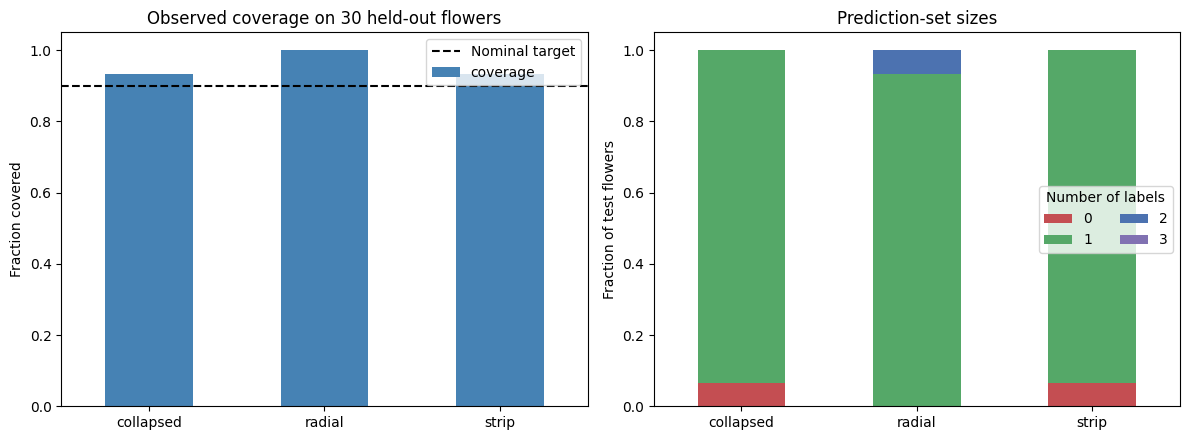

In [ ]:
size_counts = pd.DataFrame({
    method: result['set_size'].value_counts().reindex(range(len(CLASSES) + 1), fill_value=0)
    for method, result in predictions.items()}).T
size_counts.columns.name = 'set size'

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
summary['coverage'].plot.bar(ax=axes[0], color='steelblue', rot=0)
axes[0].axhline(1 - ALPHA, color='black', linestyle='--', label='Nominal target')
axes[0].set(ylim=(0, 1.05), ylabel='Fraction covered', xlabel='', title='Observed coverage on 30 held-out flowers')
axes[0].legend()
(size_counts / len(test_scores)).plot.bar(stacked=True, ax=axes[1], rot=0, color=['#c44e52', '#55a868', '#4c72b0', '#8172b2'])
axes[1].set(ylim=(0, 1.05), ylabel='Fraction of test flowers', xlabel='', title='Prediction-set sizes')
axes[1].legend(title='Number of labels', ncol=2)
plt.tight_layout()
plt.show()

## Inspecting individual outcomes



In [ ]:
inspection = predictions[SELECTED_METHOD][['ID', 'prediction_set', 'set_size', 'forced']].copy()
inspection['true_species'] = test_truth.loc[inspection['ID']].to_numpy()
inspection['covered'] = [ truth in labels for truth, labels in zip(inspection['true_species'], inspection['prediction_set'])]
display(inspection.head(10))
interesting = inspection.loc[inspection['set_size'].ne(1) | ~inspection['covered']]
if interesting.empty:
    print('For this method and split, every test prediction is a correct singleton.')
else:
    display(interesting)

,ID,prediction_set,set_size,forced,true_species,covered
0,iris_118,[virginica],1,False,virginica,True
1,iris_095,[versicolor],1,False,versicolor,True
2,iris_128,[virginica],1,False,virginica,True
3,iris_148,[virginica],1,False,virginica,True
4,iris_048,[setosa],1,False,setosa,True
5,iris_109,[virginica],1,False,virginica,True
6,iris_035,[setosa],1,False,setosa,True
7,iris_025,[setosa],1,False,setosa,True
8,iris_072,[],0,False,versicolor,False
9,iris_002,[setosa],1,False,setosa,True


,ID,prediction_set,set_size,forced,true_species,covered
8,iris_072,[],0,False,versicolor,False
17,iris_149,[],0,False,virginica,False


## Plotting envelopes 
Choose one **candidate** species and two of its score columns. We use `model.plot(...)`.

These axes should represent classifier-score nonconformity, not petal or sepal measurements. For candidate versicolor, 
low nonconformity means strong support for versicolor. Other species can have their own separate acceptance envelopes.

The model uses all three assigned scores per species; the display shows only two coordinates. 

`show_other_classes=False` avoids requesting candidate columns that the library may not store for other classes.

#### Slice of the full envelope; other coordinates fixed at training medians. Point categories use full-model decisions

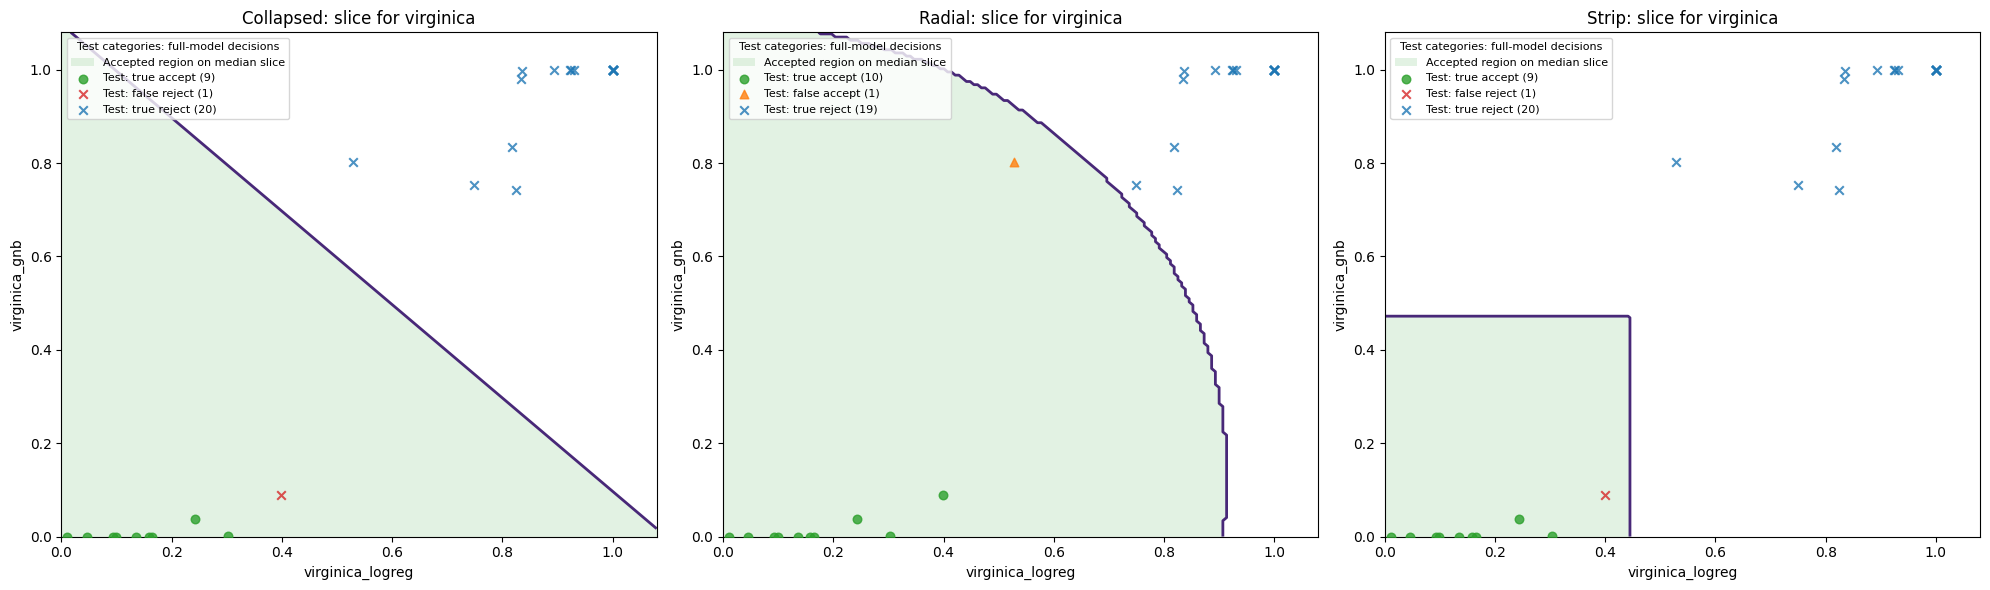

In [ ]:
PLOT_LABEL = 'virginica'  # 'versicolor' or 'setosa' or 'virginica'.
X_PREDICTOR = 'logreg'   # 'logreg' or 'knn' or 'gnb'
Y_PREDICTOR = 'gnb'

x = f'{PLOT_LABEL}_{X_PREDICTOR}'
y = f'{PLOT_LABEL}_{Y_PREDICTOR}'

# Align true labels by ID for plotting categories.
plot_test = test_scores.copy()
plot_test["label"] = test_truth.loc[plot_test["ID"]].to_numpy()

fig, axes = plt.subplots(1, len(models), figsize=(20, 6), squeeze=False,)

for ax, model in zip(axes.ravel(), models.values()):
    model.plot_slice(x=x, y=y, label=PLOT_LABEL, test_data=plot_test, show_training=False,
                     show_missing=True, ax=ax,)

plt.tight_layout()
plt.show()

#### Separate 2D fit; point categories use the 2D envelope

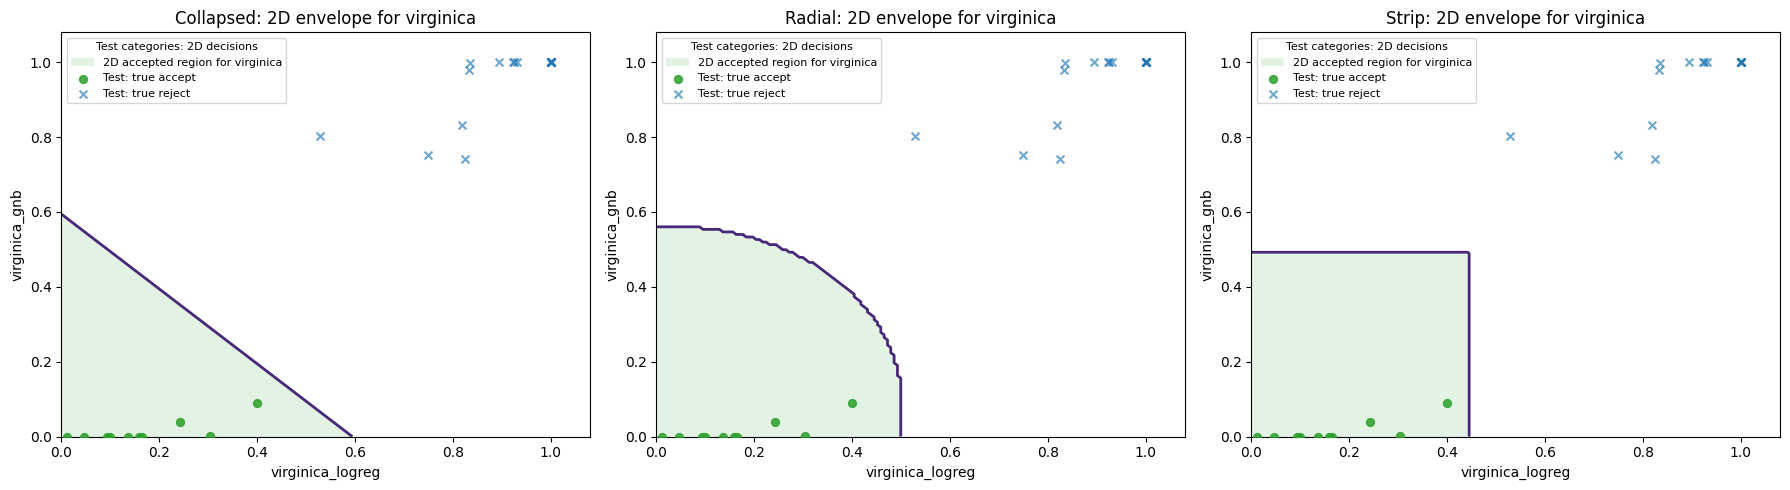

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 5), squeeze=False)

for ax, model in zip(axes.ravel(), models.values()):
    model.plot(x=x, y=y, label=PLOT_LABEL, test_data=plot_test, show_training=False, 
               show_other_classes=False, show_missing=True, ax=ax,)

plt.tight_layout()
plt.show()

### References 

- [Iris loader and dataset description](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
<!-- - [scikit-learn: avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)
- Your `synthetic_example.ipynb`: reference for the `conformal_envelopes`.

The mathematical definitions of `collapsed`, `radial`, `strip`, their missing-value rules, threshold calculation, and plot 
rendering belong to your library. This notebook demonstrates how to use that interface and keeps those implementations
in one place. -->